# Key ML & DL Imports

In [ ]:
import pandas as pd
import numpy as np
import os
import logging

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Bidirectional, LSTM, Dense, Dropout, BatchNormalization,
    Masking, Input
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# Mount Drive and Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Load data
X = np.load('/content/drive/MyDrive/X_195_75.npy')
y = np.load('/content/drive/MyDrive/y_195_75.npy')


Mounted at /content/drive


In [ ]:
MAX_SEQUENCE_LENGTH = 75
NUM_FEATURES = 195
BATCH_SIZE = 32
EPOCHS = 100
CLASSES = ['Afternoon', 'Apple', 'April', 'August', 'Banana', 'Day', 'December', 'Evening',
           'Febraury', 'Friday', 'Grapes', 'January', 'July', 'June', 'March', 'May', 'Monday',
           'Morning', 'Night', 'November', 'October', 'Orange', 'Rainy', 'Saturday', 'September',
           'Summer', 'Sunday', 'Thursday', 'Tuesday', 'Valencia_Orange', 'Watermelon', 'Wednesday', 'Winter']

NUM = len(CLASSES)

print(NUM)
print(NUM_FEATURES)

33
195


 # Data Transformation and Normalization


In [ ]:
# Normalize data
X_reshaped = X.reshape(-1, X.shape[-1])
scaler = StandardScaler()
scaler.fit(X_reshaped)
X_normalized = scaler.transform(X_reshaped)
X = X_normalized.reshape(X.shape)

print("X data normalized.")
print("X shape:", X.shape)
print("y shape:", y.shape)


X data normalized.
X shape: (2319, 75, 195)
y shape: (2319,)


In [ ]:
# Split the data into training, validation, and test sets
train_size = 0.7
val_size = 0.1
test_size = 0.2

X_train, X_rem, y_train, y_rem = train_test_split(X, y, train_size=train_size, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_rem, y_rem, test_size=(test_size/(val_size + test_size)), random_state=42, stratify=y_rem)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Convert labels to one-hot encoding
y_train_cat = to_categorical(y_train, num_classes=NUM)
y_val_cat = to_categorical(y_val, num_classes=NUM)
y_test_cat = to_categorical(y_test, num_classes=NUM)

print(f"Shape of y_train_cat: {y_train_cat.shape}")
print(f"Shape of y_val_cat: {y_val_cat.shape}")
print(f"Shape of y_test_cat: {y_test_cat.shape}")

Shape of X_train: (1623, 75, 195)
Shape of y_train: (1623,)
Shape of X_val: (232, 75, 195)
Shape of y_val: (232,)
Shape of X_test: (464, 75, 195)
Shape of y_test: (464,)
Shape of y_train_cat: (1623, 33)
Shape of y_val_cat: (232, 33)
Shape of y_test_cat: (464, 33)


# Define custom BiLSTM model

In [ ]:
# Define the improved BiLSTM model
def create_improved_bilstm_model(input_shape, num_classes, lstm_units=256, dropout_rate=0.5):
    inputs = Input(shape=input_shape)
    masked_input = Masking(mask_value=0.)(inputs)

    # First BiLSTM layer with reduced units
    x = Bidirectional(LSTM(lstm_units, return_sequences=True))(masked_input)
    x = Dropout(dropout_rate)(x)
    x = BatchNormalization()(x)

    # Second BiLSTM layer with reduced units
    x = Bidirectional(LSTM(lstm_units, return_sequences=False))(x)
    x = Dropout(dropout_rate)(x)
    x = BatchNormalization()(x)

    # Dense layers with L2 regularization
    x = Dense(lstm_units, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(dropout_rate)(x)
    x = BatchNormalization()(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    # Create and compile the model
    model = Model(inputs=inputs, outputs=outputs)
    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

# Create and summarize the model
input_shape = (MAX_SEQUENCE_LENGTH, NUM_FEATURES)
model_improved_BiLSTM = create_improved_bilstm_model(input_shape, NUM)
model_improved_BiLSTM.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 75, 195)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_11        │ (None, 75, 195)   │          0 │ input_layer_11[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_11          │ (None, 75, 195)   │          0 │ input_layer_11[0… │
│ (Masking)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_11 (Any)        │ (None, 75)        │          0 │ not_equal_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_22    │ (None, 75, 512)   │    925,696 │ masking_11[0][0], │
│ (Bidirectional)     │                   │            │ any_11[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_33          │ (None, 75, 512)   │          0 │ bidirectional_22… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 512)   │      2,048 │ dropout_33[0][0], │
│ (BatchNormalizatio… │                   │            │ any_11[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_23    │ (None, 512)       │  1,574,912 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │ any_11[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_34          │ (None, 512)       │          0 │ bidirectional_23… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dropout_34[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 256)       │    131,328 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_35          │ (None, 256)       │          0 │ dense_22[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dropout_35[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 33)        │      8,481 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,645,537 (10.09 MB)

 Trainable params: 2,642,977 (10.08 MB)

 Non-trainable params: 2,560 (10.00 KB)

In [ ]:
# Define callbacks for training
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001, verbose=1)
callbacks_list = [early_stopping, reduce_lr]

# Train the model
history = model_improved_BiLSTM.fit(
    X_train,
    y_train_cat,
    epochs=200,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val_cat),
    callbacks=callbacks_list
)

Epoch 1/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.0423 - loss: 7.3903 - val_accuracy: 0.2371 - val_loss: 6.1718 - learning_rate: 5.0000e-04
Epoch 2/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.1560 - loss: 6.3174 - val_accuracy: 0.3448 - val_loss: 5.4451 - learning_rate: 5.0000e-04
Epoch 3/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.2418 - loss: 5.6799 - val_accuracy: 0.4828 - val_loss: 4.8254 - learning_rate: 5.0000e-04
Epoch 4/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.3132 - loss: 5.0680 - val_accuracy: 0.5474 - val_loss: 4.2595 - learning_rate: 5.0000e-04
Epoch 5/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.4351 - loss: 4.5064 - val_accuracy: 0.6078 - val_loss: 3.7510 - learning_rate: 5.0000e-04
Epoch 6/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4977 - loss: 4.0397 - val_accuracy: 0.6853 - val_loss: 3.3254 - learning_rate: 5.0000e-04
Epoch 7/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 

In [ ]:
# Evaluate the model on the test set
loss, accuracy = model_improved_BiLSTM.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9267


# Save the model

In [ ]:
# Save the model
model_improved_BiLSTM.save('/content/drive/MyDrive/KSL_BiLSTM.keras')
print("Model successfully saved in .keras")

Model successfully saved in .keras


# Visualization and plots

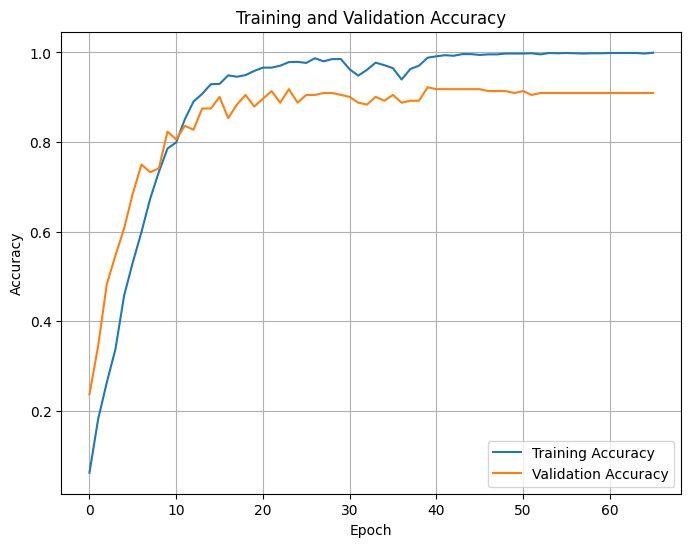

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Evaluate the model on the test set
loss, accuracy = model_improved_BiLSTM.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

# Generate predictions for the test set
y_pred = model_improved_BiLSTM.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

# Generate and print the classification report
report = classification_report(y_true_classes, y_pred_classes, target_names=CLASSES, output_dict=True)
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=CLASSES))

# Print macro, micro, and weighted average metrics
print("\nAverages:")
print("  Macro Average:")
print(f"    Precision: {report['macro avg']['precision']:.4f}")
print(f"    Recall: {report['macro avg']['recall']:.4f}")
print(f"    F1-score: {report['macro avg']['f1-score']:.4f}")
print(f"    Support: {report['macro avg']['support']}")

print("\n  Micro Average:")
print(f"    Precision: {report['accuracy']:.4f}") # Micro average precision is accuracy
print(f"    Recall: {report['accuracy']:.4f}")    # Micro average recall is accuracy
print(f"    F1-score: {report['accuracy']:.4f}")    # Micro average f1-score is accuracy
print(f"    Support: {report['accuracy'] * report['macro avg']['support']:.0f}") # Total number of samples

print("\n  Weighted Average:")
print(f"    Precision: {report['weighted avg']['precision']:.4f}")
print(f"    Recall: {report['weighted avg']['recall']:.4f}")
print(f"    F1-score: {report['weighted avg']['f1-score']:.4f}")
print(f"    Support: {report['weighted avg']['support']}")

Test Accuracy: 0.9267
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step

Classification Report:
                 precision    recall  f1-score   support

      Afternoon       1.00      1.00      1.00        12
          Apple       1.00      0.92      0.96        13
          April       1.00      0.86      0.92        14
         August       0.87      1.00      0.93        13
         Banana       0.93      1.00      0.96        13
            Day       1.00      0.92      0.96        13
       December       0.94      1.00      0.97        15
        Evening       0.85      0.85      0.85        13
       Febraury       0.86      0.86      0.86        14
         Friday       0.93      0.93      0.93        14
         Grapes       0.88      1.00      0.94        15
        January       0.93      1.00      0.97        14
           July       0.94      1.00      0.97        15
           June       0.87      0.93      0.90        14
          March       0.86      0.86      0.86        14
 

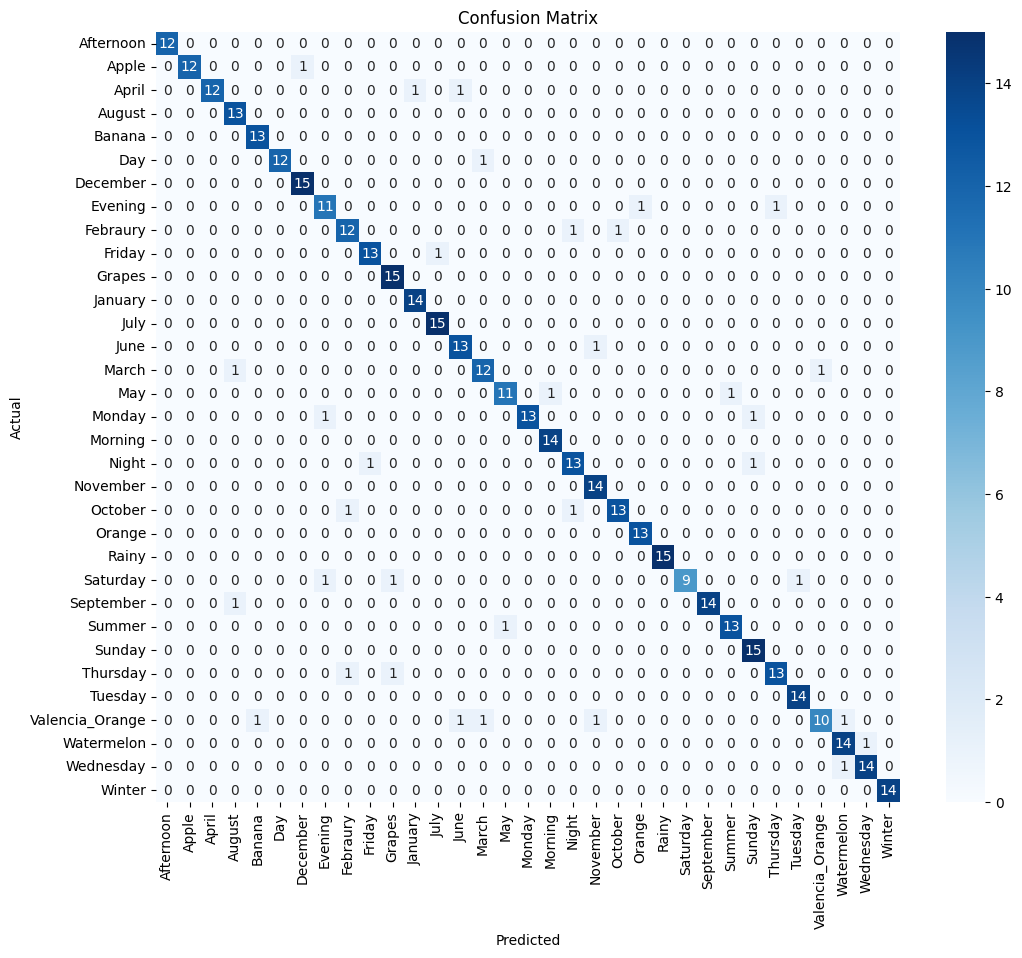

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()